# SQL Analysis — RFM in SQL + Business Queries

`segmentation.ipynb` builds RFM features and clusters customers in **pandas**.
This notebook does the same core feature engineering in **SQL** instead — plus
a handful of analyst-style queries (monthly revenue trend, top products,
repeat-purchase rate, cohort retention, and a window-function query over the
cluster output) that show SQL depth beyond a single `GROUP BY`.

**Engine:** every query actually *runs* on SQLite, via Python's built-in
`sqlite3` — no server to install, so this notebook works for anyone who opens
it with zero setup. **Every query below also has a MySQL rewrite** in the
markdown cell right after it — real, correct MySQL 8.0+ syntax (not just a
note about function names), so the SQL itself is what gets read, not a
translation table.</cell id="1d9a51e4">

In [1]:
import sqlite3
import pandas as pd
from pathlib import Path

BASE = Path.cwd()
DATA = BASE / "data"
OUT = BASE / "outputs"
OUT.mkdir(exist_ok=True)

DB_PATH = OUT / "retail.db"
if DB_PATH.exists():
    DB_PATH.unlink()  # rebuild fresh each run
conn = sqlite3.connect(DB_PATH)

## 1. Load & clean, then push into SQLite

Same cleaning rules as `segmentation.ipynb` — including the non-product
`StockCode` exclusion (postage, carriage, manual adjustments, bank charges;
see that notebook's §1 for how that was found) — kept here so this notebook
runs standalone. Everything *after* this cell is SQL.

In [2]:
df = pd.read_excel(DATA / "Online Retail.xlsx")
df = df.dropna(subset=["CustomerID"])
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

NON_PRODUCT_CODES = {"POST", "DOT", "D", "M", "m", "BANK CHARGES", "C2", "CRUK", "S", "AMAZONFEE", "B"}
df = df[~df["StockCode"].astype(str).isin(NON_PRODUCT_CODES)]

q_hi = df["Quantity"].quantile(0.999)
p_hi = df["UnitPrice"].quantile(0.999)
df = df[(df["Quantity"] <= q_hi) & (df["UnitPrice"] <= p_hi)]
df["CustomerID"] = df["CustomerID"].astype(int)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df.to_sql("transactions", conn, if_exists="replace", index=False)
print(f"Loaded {len(df):,} rows into transactions table")
pd.read_sql("SELECT * FROM transactions LIMIT 5", conn)

Loaded 395,555 rows into transactions table


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


## 2. RFM, computed entirely in SQL

Recency needs a snapshot date (one day after the last transaction) and the
gap in days to each customer's last order — `julianday()` is SQLite's way of
getting a numeric day difference; in Postgres you'd write
`snapshot_date - last_order`, in MySQL `DATEDIFF(snapshot_date, last_order)`.

**A gotcha worth knowing:** the first version of this query used SQLite's
`date(MAX(InvoiceDate), '+1 day')` for the snapshot, which silently truncates
to midnight — so it lost the time-of-day that `last_order` still carries,
producing an off-by-one Recency for any customer whose last order fell on the
dataset's final day. Using `julianday()` (full floating-point precision) on
*both* sides instead of `date()` keeps them on the same footing. The
validation check in the next cell is what caught this.

In [3]:
rfm_sql = """
WITH snapshot AS (
    SELECT julianday(MAX(InvoiceDate)) + 1 AS snapshot_jd
    FROM transactions
),
customer_orders AS (
    SELECT
        CustomerID,
        MAX(InvoiceDate)                    AS last_order,
        COUNT(DISTINCT InvoiceNo)           AS Frequency,
        ROUND(SUM(Quantity * UnitPrice), 2) AS Monetary
    FROM transactions
    GROUP BY CustomerID
)
SELECT
    co.CustomerID,
    CAST(s.snapshot_jd - julianday(co.last_order) AS INTEGER) AS Recency,
    co.Frequency,
    co.Monetary
FROM customer_orders co
CROSS JOIN snapshot s
ORDER BY co.CustomerID;
"""

rfm_from_sql = pd.read_sql(rfm_sql, conn)
print(f"{len(rfm_from_sql):,} customers")
rfm_from_sql.head()

4,318 customers


,CustomerID,Recency,Frequency,Monetary
0,12347,2,7,4310.00
1,12348,75,4,1437.24
2,12349,19,1,1417.60
3,12350,310,1,294.40
4,12352,36,7,1385.74


**MySQL version** (8.0+, for CTE + window function support):

```sql
WITH snapshot AS (
    SELECT DATE_ADD(MAX(InvoiceDate), INTERVAL 1 DAY) AS snapshot_date
    FROM transactions
),
customer_orders AS (
    SELECT
        CustomerID,
        MAX(InvoiceDate)                    AS last_order,
        COUNT(DISTINCT InvoiceNo)           AS Frequency,
        ROUND(SUM(Quantity * UnitPrice), 2) AS Monetary
    FROM transactions
    GROUP BY CustomerID
)
SELECT
    co.CustomerID,
    DATEDIFF(s.snapshot_date, co.last_order) AS Recency,
    co.Frequency,
    co.Monetary
FROM customer_orders co
CROSS JOIN snapshot s
ORDER BY co.CustomerID;
```

`DATEDIFF(a, b)` in MySQL compares only the **date** part of both arguments —
it ignores time-of-day on both sides equally, so it doesn't reproduce the
SQLite bug from above (that bug came from truncating *only one side*). This
is also the conventional way RFM Recency is computed in practice — whole
calendar days, not fractional. If you needed exact 24-hour-period precision
instead, `TIMESTAMPDIFF(DAY, co.last_order, s.snapshot_date)` is the
alternative, with slightly different rounding at day boundaries.

## 3. Validate against the pandas version

The same RFM logic already exists in `segmentation.ipynb`, written in pandas.
Recomputing it here in SQL and diffing the two is a good sanity check — and a
good interview answer to *"how do you know your SQL is right?"*

In [4]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
rfm_from_pandas = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Quantity", lambda x: None),  # placeholder, recomputed below
).reset_index()
rfm_from_pandas["Monetary"] = df.groupby("CustomerID").apply(
    lambda g: round((g["Quantity"] * g["UnitPrice"]).sum(), 2), include_groups=False
).values

merged = rfm_from_sql.merge(rfm_from_pandas, on="CustomerID", suffixes=("_sql", "_pandas"))
max_diff_recency = (merged["Recency_sql"] - merged["Recency_pandas"]).abs().max()
max_diff_frequency = (merged["Frequency_sql"] - merged["Frequency_pandas"]).abs().max()
max_diff_monetary = (merged["Monetary_sql"] - merged["Monetary_pandas"]).abs().max()

print(f"Max abs diff — Recency: {max_diff_recency}, Frequency: {max_diff_frequency}, Monetary: {max_diff_monetary}")
assert max_diff_recency == 0 and max_diff_frequency == 0 and max_diff_monetary < 0.01
print("SQL and pandas RFM match exactly.")

Max abs diff — Recency: 0, Frequency: 0, Monetary: 0.0
SQL and pandas RFM match exactly.


## 4. Bonus business queries

Four queries an analyst would actually be asked to write — deliberately
reaching for `GROUP BY` + date functions, then a `CTE`, then a **window
function**, so the range of SQL used here is broader than just the RFM
aggregation above.

### 4a. Monthly revenue trend

In [5]:
monthly_revenue = pd.read_sql("""
    SELECT
        strftime('%Y-%m', InvoiceDate) AS month,
        ROUND(SUM(Quantity * UnitPrice), 2) AS revenue,
        COUNT(DISTINCT InvoiceNo) AS orders
    FROM transactions
    GROUP BY month
    ORDER BY month;
""", conn)
monthly_revenue

,month,revenue,orders
0,2010-12,532420.32,1386
1,2011-01,439288.32,968
2,2011-02,428292.92,985
3,2011-03,558561.36,1304
4,2011-04,420559.61,1135
5,2011-05,629137.50,1531
6,2011-06,582837.61,1380
7,2011-07,580253.39,1314
8,2011-08,612977.56,1260
9,2011-09,882902.20,1731


**MySQL version:**

```sql
SELECT
    DATE_FORMAT(InvoiceDate, '%Y-%m') AS month,
    ROUND(SUM(Quantity * UnitPrice), 2) AS revenue,
    COUNT(DISTINCT InvoiceNo) AS orders
FROM transactions
GROUP BY month
ORDER BY month;
```

Only change from SQLite: `strftime('%Y-%m', ...)` becomes
`DATE_FORMAT(..., '%Y-%m')` — same format-string idea, different function
name.

### 4b. Top 10 products by revenue

In [6]:
top_products = pd.read_sql("""
    SELECT
        Description,
        SUM(Quantity) AS units_sold,
        ROUND(SUM(Quantity * UnitPrice), 2) AS revenue
    FROM transactions
    GROUP BY Description
    ORDER BY revenue DESC
    LIMIT 10;
""", conn)
top_products

,Description,units_sold,revenue
0,REGENCY CAKESTAND 3 TIER,12402,142592.95
1,WHITE HANGING HEART T-LIGHT HOLDER,29743,81172.33
2,JUMBO BAG RED RETROSPOT,42981,79660.78
3,PARTY BUNTING,15291,68844.33
4,ASSORTED COLOUR BIRD ORNAMENT,30314,49260.74
5,CHILLI LIGHTS,9650,46286.51
6,PAPER CHAIN KIT 50'S CHRISTMAS,13985,38499.23
7,DOORMAT KEEP CALM AND COME IN,5342,35913.85
8,BLACK RECORD COVER FRAME,10446,35810.15
9,SPOTTY BUNTING,7639,35539.25


**MySQL version:** identical — no date functions involved, so this query is
already standard SQL with nothing to translate:

```sql
SELECT
    Description,
    SUM(Quantity) AS units_sold,
    ROUND(SUM(Quantity * UnitPrice), 2) AS revenue
FROM transactions
GROUP BY Description
ORDER BY revenue DESC
LIMIT 10;
```

### 4c. Repeat-purchase rate

What share of customers placed more than one order — a number that directly
motivates *why* segmentation matters (most customers are one-and-done; the
"Champions" segment is the exception, not the rule).

In [7]:
repeat_rate = pd.read_sql("""
    SELECT
        ROUND(100.0 * SUM(CASE WHEN order_count > 1 THEN 1 ELSE 0 END) / COUNT(*), 1) AS repeat_customer_pct
    FROM (
        SELECT CustomerID, COUNT(DISTINCT InvoiceNo) AS order_count
        FROM transactions
        GROUP BY CustomerID
    );
""", conn)
repeat_rate

,repeat_customer_pct
0,65.1


**MySQL version:**

```sql
SELECT
    ROUND(100.0 * SUM(CASE WHEN order_count > 1 THEN 1 ELSE 0 END) / COUNT(*), 1) AS repeat_customer_pct
FROM (
    SELECT CustomerID, COUNT(DISTINCT InvoiceNo) AS order_count
    FROM transactions
    GROUP BY CustomerID
) AS customer_orders;
```

A real dialect difference here, not just a function rename: MySQL **requires**
an alias on a derived table (`AS customer_orders`) — SQLite is lenient and
lets you leave it unaliased, which the query above does. Forgetting the alias
is one of the most common "works on SQLite, breaks on MySQL" mistakes.

### 4d. Monthly cohort retention

Classic SQL interview question: group customers by the month of their *first*
purchase (their cohort), then track how many of each cohort are still active
in later months. Uses a CTE for the first-purchase lookup, then a join +
aggregation to build the cohort grid. This count grid is the audit view —
turned into a **retention-percentage** heatmap below, which is the version
that's actually useful for a business reader (a shrinking cohort in absolute
numbers is expected as new cohorts are smaller; the *rate* at which each
cohort shrinks is the signal).</cell id="4c202639">

In [8]:
cohort_sql = """
WITH first_purchase AS (
    SELECT CustomerID, MIN(strftime('%Y-%m', InvoiceDate)) AS cohort_month
    FROM transactions
    GROUP BY CustomerID
),
activity AS (
    SELECT DISTINCT CustomerID, strftime('%Y-%m', InvoiceDate) AS order_month
    FROM transactions
)
SELECT
    fp.cohort_month,
    a.order_month,
    COUNT(DISTINCT a.CustomerID) AS active_customers
FROM activity a
JOIN first_purchase fp ON a.CustomerID = fp.CustomerID
GROUP BY fp.cohort_month, a.order_month
ORDER BY fp.cohort_month, a.order_month;
"""

cohort_long = pd.read_sql(cohort_sql, conn)
cohort_pivot = cohort_long.pivot(index="cohort_month", columns="order_month", values="active_customers")
cohort_pivot

order_month,2010-12,2011-01,2011-02,2011-03,2011-04,2011-05,2011-06,2011-07,2011-08,2011-09,2011-10,2011-11,2011-12
cohort_month,,,,,,,,,,,,,
2010-12,878.0,320.0,283.0,335.0,320.0,350.0,319.0,305.0,309.0,346.0,329.0,442.0,234.0
2011-01,NaN,410.0,92.0,112.0,94.0,131.0,119.0,104.0,100.0,124.0,136.0,152.0,48.0
2011-02,NaN,NaN,378.0,71.0,71.0,108.0,102.0,91.0,97.0,103.0,93.0,115.0,26.0
2011-03,NaN,NaN,NaN,451.0,67.0,112.0,90.0,101.0,75.0,119.0,104.0,125.0,38.0
2011-04,NaN,NaN,NaN,NaN,299.0,63.0,61.0,62.0,58.0,68.0,65.0,78.0,22.0
2011-05,NaN,NaN,NaN,NaN,NaN,282.0,55.0,49.0,50.0,59.0,65.0,75.0,26.0
2011-06,NaN,NaN,NaN,NaN,NaN,NaN,242.0,42.0,38.0,64.0,54.0,79.0,23.0
2011-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,189.0,34.0,38.0,42.0,50.0,21.0
2011-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.0,33.0,41.0,41.0,21.0


**MySQL version:**

```sql
WITH first_purchase AS (
    SELECT CustomerID, MIN(DATE_FORMAT(InvoiceDate, '%Y-%m')) AS cohort_month
    FROM transactions
    GROUP BY CustomerID
),
activity AS (
    SELECT DISTINCT CustomerID, DATE_FORMAT(InvoiceDate, '%Y-%m') AS order_month
    FROM transactions
)
SELECT
    fp.cohort_month,
    a.order_month,
    COUNT(DISTINCT a.CustomerID) AS active_customers
FROM activity a
JOIN first_purchase fp ON a.CustomerID = fp.CustomerID
GROUP BY fp.cohort_month, a.order_month
ORDER BY fp.cohort_month, a.order_month;
```

Same `strftime` → `DATE_FORMAT` swap as the monthly revenue query; the CTEs,
join, and `GROUP BY` are unchanged. This needs MySQL 8.0+ — CTEs
(`WITH ...`) aren't available before that.

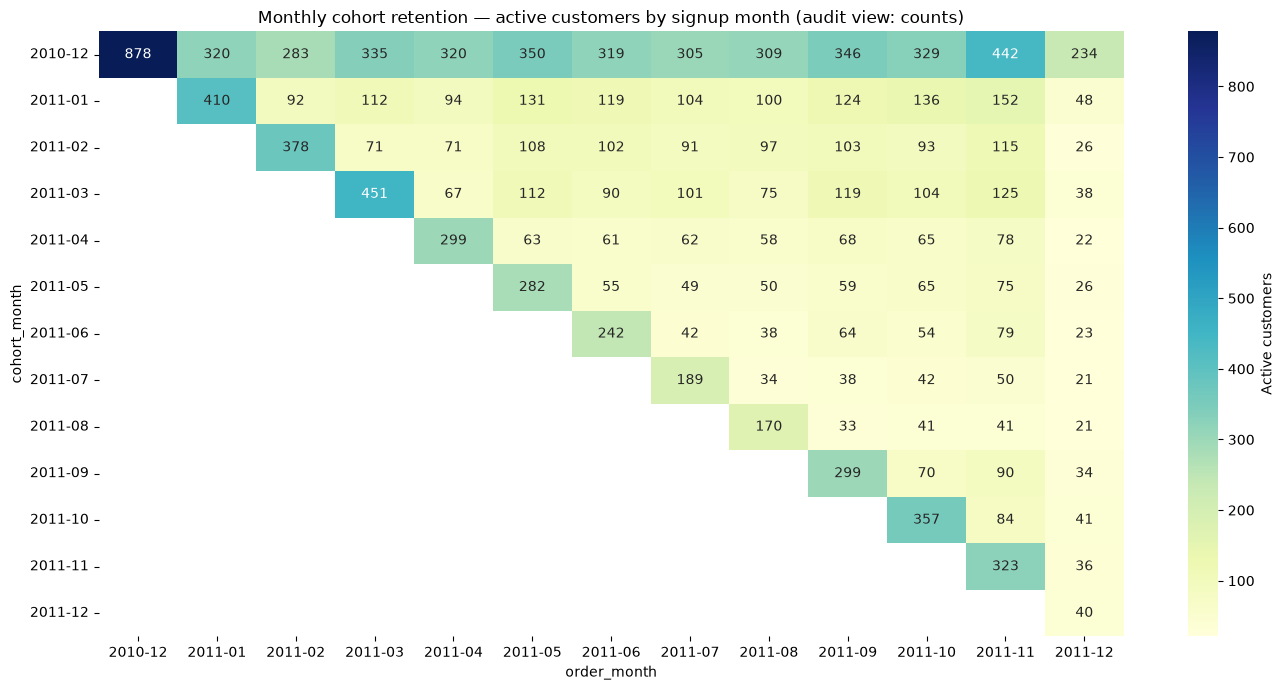

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(cohort_pivot, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax, cbar_kws={"label": "Active customers"})
ax.set_title("Monthly cohort retention — active customers by signup month (audit view: counts)")
plt.tight_layout()
plt.savefig(OUT / "cohort_retention_counts.png", dpi=150)
plt.show()

### 4d (continued). The same grid, as retention percentages

Re-index columns by **months since first purchase** (Month 0, Month 1, ...)
instead of calendar month, then divide every row by its own Month 0 value.
This is the primary business visualization — a business reader can compare
"what % of a cohort is still active by Month 3" across cohorts, which a raw
calendar-month count grid doesn't let you do at a glance.

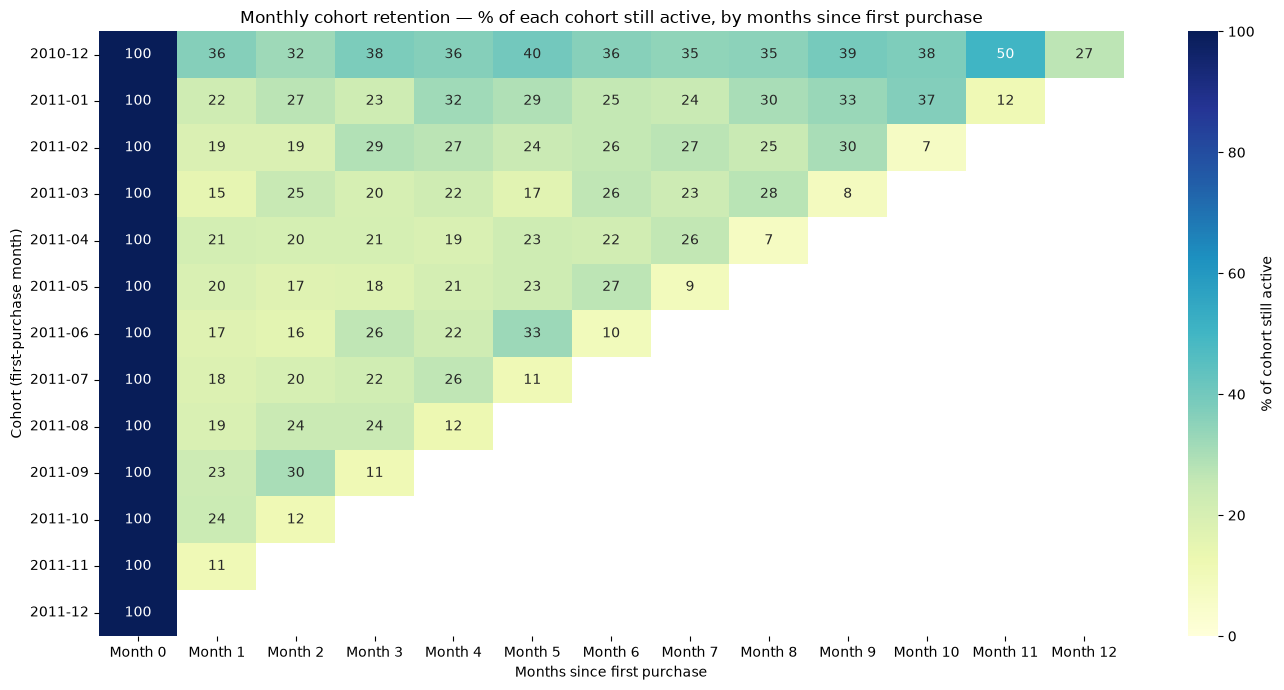

In [10]:
cohort_long["cohort_period"] = pd.PeriodIndex(cohort_long["cohort_month"], freq="M")
cohort_long["order_period"] = pd.PeriodIndex(cohort_long["order_month"], freq="M")
cohort_long["month_offset"] = (cohort_long["order_period"] - cohort_long["cohort_period"]).apply(lambda p: p.n)

cohort_offset_pivot = cohort_long.pivot(index="cohort_month", columns="month_offset", values="active_customers")
cohort_offset_pivot.columns = [f"Month {c}" for c in cohort_offset_pivot.columns]

retention_pct = cohort_offset_pivot.div(cohort_offset_pivot["Month 0"], axis=0).mul(100).round(1)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(retention_pct, annot=True, fmt=".0f", cmap="YlGnBu", vmin=0, vmax=100,
            ax=ax, cbar_kws={"label": "% of cohort still active"})
ax.set_title("Monthly cohort retention — % of each cohort still active, by months since first purchase")
ax.set_xlabel("Months since first purchase")
ax.set_ylabel("Cohort (first-purchase month)")
plt.tight_layout()
plt.savefig(OUT / "cohort_retention.png", dpi=150)
plt.show()

### 4e. Window function: top 3 customers within each RFM segment

Ties the SQL work back to the clustering output from `segmentation.ipynb`.
Loads `outputs/rfm_table.csv` (the per-customer segment assignments) into
SQLite, then uses `RANK() OVER (PARTITION BY ... ORDER BY ...)` to pull the
top 3 spenders *within* each segment — the query a marketing team would
actually run to build a "VIP Champions" contact list.

In [11]:
rfm_segments_path = OUT / "rfm_table.csv"
if rfm_segments_path.exists():
    rfm_segments = pd.read_csv(rfm_segments_path)
    rfm_segments.to_sql("rfm", conn, if_exists="replace", index=False)

    top_per_segment = pd.read_sql("""
        WITH ranked AS (
            SELECT
                CustomerID, Segment, Recency, Frequency, Monetary,
                RANK() OVER (PARTITION BY Segment ORDER BY Monetary DESC) AS rnk
            FROM rfm
        )
        SELECT CustomerID, Segment, Recency, Frequency, Monetary
        FROM ranked
        WHERE rnk <= 3
        ORDER BY Segment, rnk;
    """, conn)
    top_per_segment
else:
    print("Run segmentation.ipynb first to generate outputs/rfm_table.csv, "
          "then re-run this cell.")
    top_per_segment = None
top_per_segment

,CustomerID,Segment,Recency,Frequency,Monetary
0,12409,0,79,3,11072.67
1,16180,0,100,8,10254.18
2,12590,0,211,1,8951.26
3,14646,1,2,69,263972.26
4,18102,1,1,60,237641.30
5,14911,1,1,198,135773.37
6,12501,2,337,1,2025.39
7,17597,2,214,1,2004.42
8,16152,2,269,1,1829.04
9,15123,3,7,2,2199.31


**MySQL version:** identical — `RANK() OVER (PARTITION BY ... ORDER BY ...)`
is standard SQL:2003 window-function syntax, supported the same way in
SQLite (3.25+), MySQL (8.0+), and Postgres:

```sql
WITH ranked AS (
    SELECT
        CustomerID, Segment, Recency, Frequency, Monetary,
        RANK() OVER (PARTITION BY Segment ORDER BY Monetary DESC) AS rnk
    FROM rfm
)
SELECT CustomerID, Segment, Recency, Frequency, Monetary
FROM ranked
WHERE rnk <= 3
ORDER BY Segment, rnk;
```

### 4f. Segment-level business KPIs, computed in SQL

One query that ties the SQL layer directly to the headline numbers used in
the main narrative — customer count, revenue, and revenue share per segment
— using a window function (`SUM(...) OVER ()`) to get the grand total
alongside each group's row without a second query or a self-join.

In [12]:
if rfm_segments_path.exists():
    segment_kpis = pd.read_sql("""
        SELECT
            Segment,
            COUNT(DISTINCT CustomerID) AS customers,
            ROUND(SUM(Monetary), 2) AS revenue,
            ROUND(100.0 * SUM(Monetary) / SUM(SUM(Monetary)) OVER (), 2) AS revenue_share_pct,
            ROUND(AVG(Monetary), 2) AS avg_customer_value
        FROM rfm
        GROUP BY Segment
        ORDER BY revenue DESC;
    """, conn)
else:
    print("Run segmentation.ipynb first to generate outputs/rfm_table.csv.")
    segment_kpis = None
segment_kpis

,Segment,customers,revenue,revenue_share_pct,avg_customer_value
0,1,699,5179132.88,64.35,7409.35
1,0,1178,1893770.63,23.53,1607.62
2,2,1612,538676.44,6.69,334.17
3,3,829,436361.79,5.42,526.37


**MySQL version:** identical — `SUM(...) OVER ()` (a window function applied
to an already-aggregated value, after the `GROUP BY`) is standard SQL,
supported the same way in SQLite 3.25+, MySQL 8.0+, and Postgres:

```sql
SELECT
    Segment,
    COUNT(DISTINCT CustomerID) AS customers,
    ROUND(SUM(Monetary), 2) AS revenue,
    ROUND(100.0 * SUM(Monetary) / SUM(SUM(Monetary)) OVER (), 2) AS revenue_share_pct,
    ROUND(AVG(Monetary), 2) AS avg_customer_value
FROM rfm
GROUP BY Segment
ORDER BY revenue DESC;
```

## Takeaway

Every number in `segmentation.ipynb` — Recency, Frequency, Monetary — can be
reproduced with a `GROUP BY` and a couple of date functions; no pandas
required. The heavier SQL here (CTEs, window functions, cohort joins) is the
kind an analyst is actually asked to write day-to-day, independent of any
clustering model — and §4f closes the loop by computing the exact
segment-revenue numbers used in the main narrative directly in SQL, not just
in pandas.</cell id="1f2e55db">

In [13]:
conn.close()
print("Done. retail.db, cohort_retention.png (percentages), and cohort_retention_counts.png (audit view) written to outputs/")

Done. retail.db, cohort_retention.png (percentages), and cohort_retention_counts.png (audit view) written to outputs/
